In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data1.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [4]:
df.dtypes

Дата            object
Склад            int64
Контрагент      object
Номенклатура    object
Количество       int64
dtype: object

Сразу переведем столбец "Дата" в правильный формат

In [5]:
df["Дата"] = pd.to_datetime(df["Дата"])

Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = (df.groupby("Дата").size().reset_index(name="Количество продаж"))

Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  Количество продаж
0 2018-01-04               1840
1 2018-01-05               1301
2 2018-01-06               1306
3 2018-01-07               1322
4 2018-01-09               1719


Нарисуйте график продаж у `grouped_df`

<Axes: xlabel='Дата'>

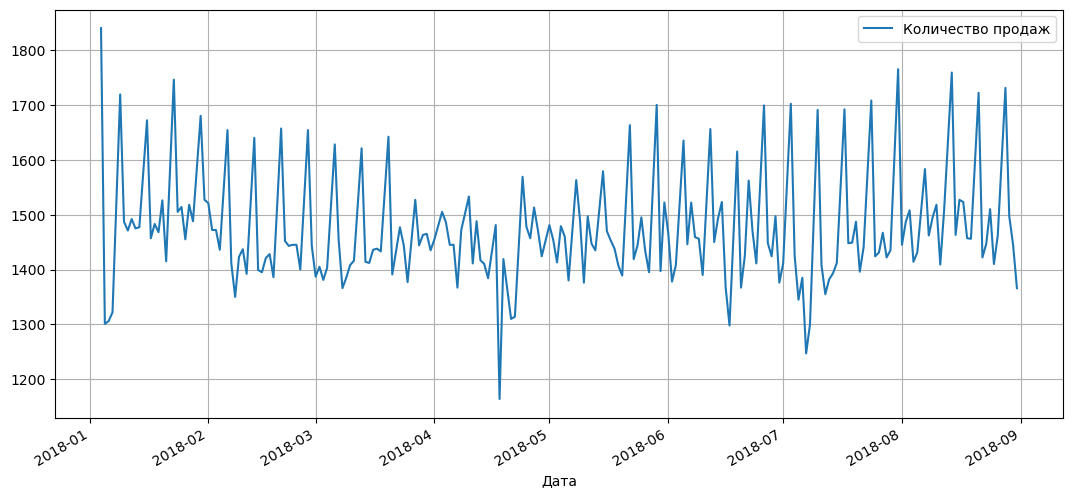

In [8]:
grouped_df.plot(x= "Дата", y= "Количество продаж", kind= "line", grid=True, figsize=(13, 6))

Опишите что вы видите на графике. Ваша задача - максимально описать график

In [80]:
На графике видны повторяющиеся циклы с регулярными резкими пиками и спадами. Пики подъемов в среднем
происходят 4 раза в месяц, похоже на недельную сезонность. Во время пиковых дней продажи резко возрастают
до примрно 1600–1800 единиц, во время спада продажи регулярно падают до около 1200–1400.
С Января по Март продажи стабильно колеблятся в высоком коридоре (пики доходят до 1650–1850, спады редко 
опускаются ниже 1350).
В Апреле до середины Мая наблюдается общий спад продаж: пиковые значения проседают (не поднимаются выше 
1550), а средний уровень продаж временно снижается.
В конце Мая до Августа происходит заметное восстановление объемов. Пиковые точки снова возвращаются к
отметкам 1700–1750 продаж, а общая амплитуда колебаний становится более размашистой.
Абсолютный максимум продаж: Самая первая точка графика (4 января 2018 года) показывает
максимальный пик за всё время — выше 1800 продаж. Это может быть связано с заказами во время Новогодних
продаж.Затем сразу же видим резкое снижение продаж до 1300.
Абсолютный минимум мы видим в середине апреля: ниже 1200 продаж (примерно 1150). 
Также мы видим сильное падение продаж в начале Июля: примерно до 1250 продаж.

SyntaxError: invalid character '–' (U+2013) (842079864.py, line 3)

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [81]:
Q1 = df["Количество"].quantile(0.25)
Q3 = df["Количество"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

outliers = df[df["Количество"] > upper_bound]
max_outlier_row = outliers.loc[outliers["Количество"].idxmax()]

print(f"Верхняя граница нормы: {upper_bound}")
print("Строка с максимальным статистическим выбросом:")
print(max_outlier_row)

Верхняя граница нормы: 8.5
Строка с максимальным статистическим выбросом:
Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [70]:
filtered_df = df[
    (df["Склад"] == 3)
    & (df["Дата"].dt.month.isin([6, 7, 8])) 
    & (df["Дата"].dt.weekday == 2)
]
top_product = (
    filtered_df.groupby("Номенклатура")["Количество"]
    .sum()
    .reset_index()
    .sort_values(by="Количество", ascending=False)
    .iloc[0] 
)
print(f"Топовый товар на 3 складе: {top_product['Номенклатура']}")
print(f"Суммарное количество продаж по средам за лето: {top_product['Количество']} шт.")

Топовый товар на 3 складе: product_1
Суммарное количество продаж по средам за лето: 2267 шт.


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [71]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


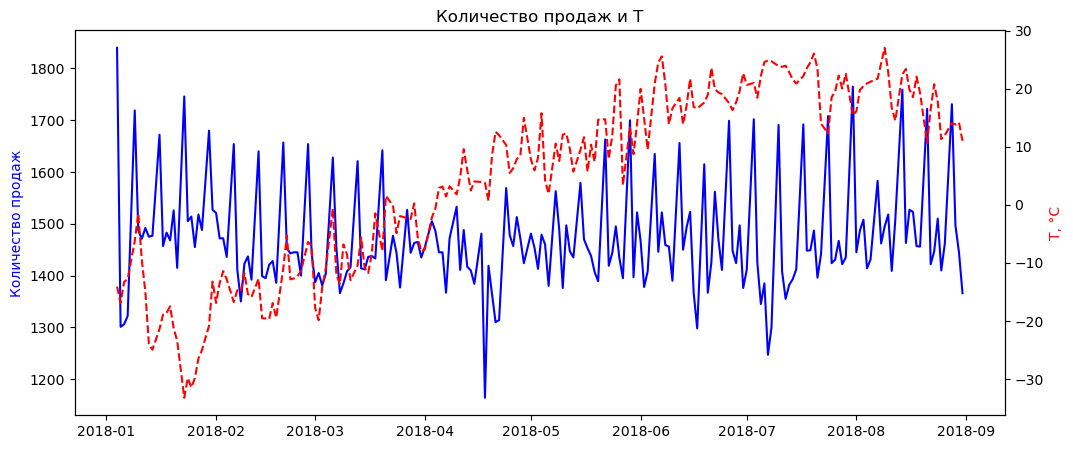

In [75]:
weather = pd.read_excel('погода в астане.xls', decimal=',', engine='xlrd')
weather['Дата'] = pd.to_datetime(weather['Дата'], format='%d.%m.%Y %H:%M').dt.date
weather_daily = weather.groupby('Дата')['T'].mean().reset_index()

grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.date

final_df = pd.merge(grouped_df, weather_daily, on='Дата').sort_values('Дата')

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(final_df['Дата'], final_df['Количество продаж'], color='blue', label='Количество продаж')
ax2.plot(final_df['Дата'], final_df['T'], color='red', linestyle='--', label='T')

ax1.set_ylabel('Количество продаж', color='blue')
ax2.set_ylabel('T, °C', color='red')
plt.title('Количество продаж и T')
plt.show()
